# Lazypredict

In [29]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd

In [30]:
# Data Preparation
df = pd.read_excel("Final_PM15.xlsx")

# Cleaning
df['MDWT'] = pd.to_numeric(df['MDWT'], errors='coerce')
df = df.dropna()

# Cleaning - GSM
df['GSM'] = df['GSM'].astype(str)
df = df[df['GSM'].str.len() <= 4].copy()
df['GSM'] = df['GSM'].str.replace(',', '.')
df['GSM'] = df['GSM'].astype(float)

# X Variables
features = [
    '% NBKP', #1
    '% BB Recycle',
    'Mean_Yankee Speed',
    'Mean_Stock Flow',
    'Mean_Flow Coating',
    'Mean_Load KWH Refiner', #2
    'Mean_Stock Consistency', #3
    'Mean_Creping', #4
    'Mean_Jet Wire Ratio' #5
]
X = df[features]

# Y Variables
target = 'MDT'
y = df[target]

In [31]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

In [33]:
# Hitung MAPE untuk tiap model
mape_scores = {}

for model_name, y_pred in predictions.items():
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mape_scores[model_name] = mape

# Tambahkan ke tabel hasil
models["MAPE"] = pd.Series(mape_scores)

# Urutkan (semakin kecil semakin baik)
models = models.sort_values(by="MAPE")

In [34]:
print(models)

                               Adjusted R-Squared   R-Squared         RMSE  \
Model                                                                        
BaggingRegressor                         0.825649    0.869237    70.509535   
ExtraTreesRegressor                      0.823057    0.867293    71.031690   
RandomForestRegressor                    0.816081    0.862061    72.418473   
Lasso                                    0.809532    0.857149    73.696557   
LassoLarsIC                              0.809493    0.857120    73.703964   
LassoLars                                0.809474    0.857105    73.707789   
LarsCV                                   0.809226    0.856919    73.755725   
LassoLarsCV                              0.809226    0.856919    73.755725   
LassoCV                                  0.809131    0.856849    73.773941   
OrthogonalMatchingPursuitCV              0.807827    0.855870    74.025546   
LinearRegression                         0.805879    0.854409   

# Random Forest Regressor

In [35]:
# Import Libraries
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load Data -> sudah sebelumnya
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Inisialisasi Model Random Forest
rf = RandomForestRegressor(
    n_estimators=200,     # jumlah pohon
    max_depth=None,       # kedalaman pohon (None = bebas)
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1             # gunakan semua core CPU
)

# Training Model
rf.fit(X_train, y_train)
# Prediksi
y_pred = rf.predict(X_test)

# Evaluasi Model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# MAPE Manual (aman)
epsilon = 1e-8
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon)))

print("R2       :", r2)
print("RMSE     :", rmse)
print("MAE      :", mae)
print("MAPE     :", mape)

R2       : 0.859756414911394
RMSE     : 73.02079651570585
MAE      : 51.7743993993994
MAPE     : 0.0756100726535035


### Features Importance

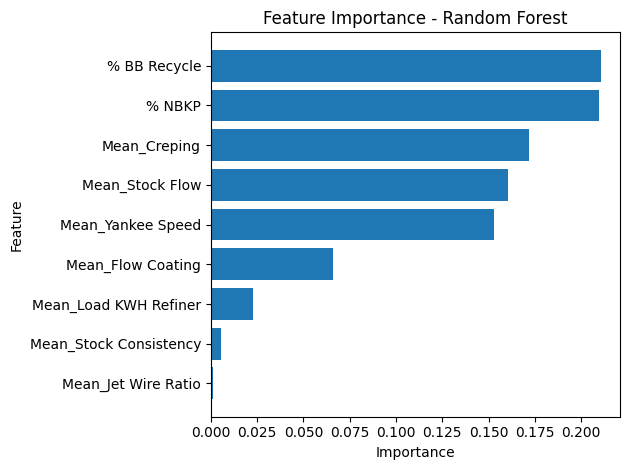

In [36]:
# Feature Importance
import pandas as pd

feat_imp = pd.DataFrame({
    "Feature": features, 
    "Importance": rf.feature_importances_
})

# Urutkan dari terbesar
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)


# Plot
import matplotlib.pyplot as plt
plt.figure()
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")

plt.tight_layout()
plt.show()

### SHAP Analysis

In [37]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [38]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

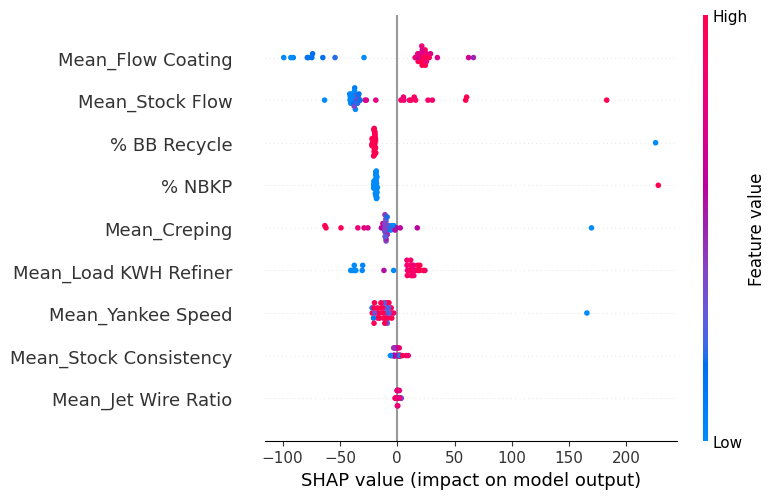

In [39]:
shap.summary_plot(shap_values, X_test, feature_names=features)

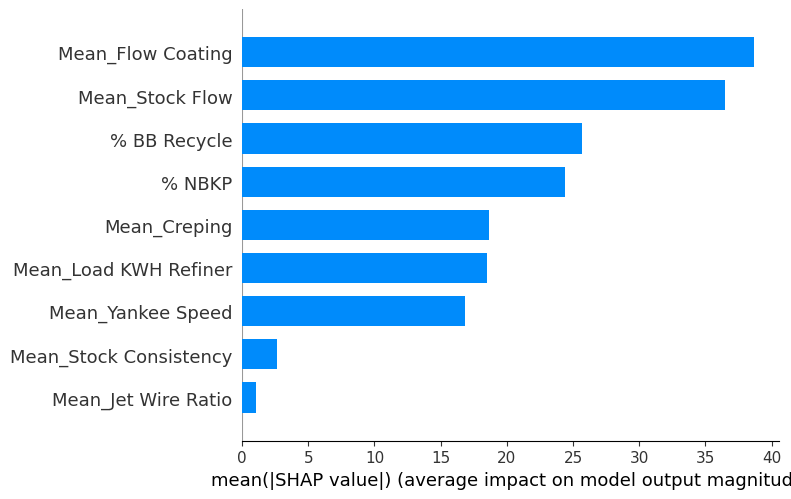

In [40]:
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=features)

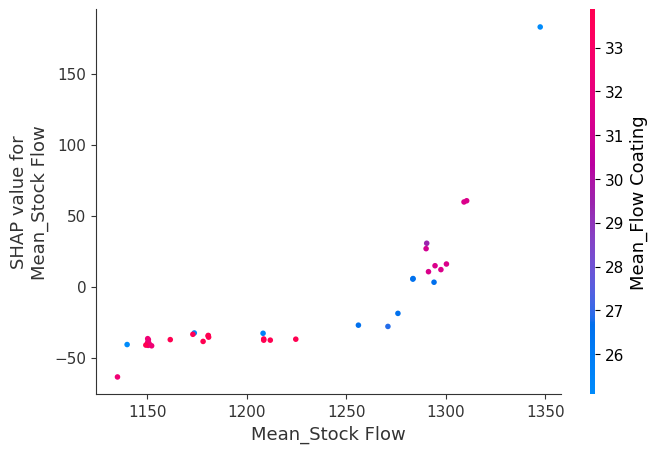

In [41]:
shap.dependence_plot("Mean_Stock Flow", shap_values, X_test, feature_names=features)

In [42]:
shap_values = explainer.shap_values(np.array(X_test))
shap.initjs()
i = 0  # index data

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i]
)